### Импорт библиотек

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import ssl
import urllib

### Инициализация констант

In [2]:
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
NUM_EPOCHS = 40

DATASET_PATH = "dataset/dogs-vs-cats-split"
if not Path(DATASET_PATH).exists():
    print("Данные не найдены. Завершение работы.")
    raise SystemExit("Данные должны были быть предобработаны во втором этапе")

### Предобработка данных

In [3]:
# Создание генераторов данных без аугментации (для feature extraction)
print("Создание генераторов данных...")

datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = datagen.flow_from_directory(
    f"{DATASET_PATH}/train",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

validation_generator = datagen.flow_from_directory(
    f"{DATASET_PATH}/val",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_generator = datagen.flow_from_directory(
    f"{DATASET_PATH}/test",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Размер тренировочной выборки: {train_generator.samples}")
print(f"Размер валидационной выборки: {validation_generator.samples}")
print(f"Размер тестовой выборки: {test_generator.samples}")

Создание генераторов данных...
Found 24371 images belonging to 2 classes.
Found 14774 images belonging to 2 classes.
Found 14754 images belonging to 2 classes.
Размер тренировочной выборки: 24371
Размер валидационной выборки: 14774
Размер тестовой выборки: 14754


### Загрузка предобученной модели и обучение

In [4]:
print("\nЗагрузка предобученной модели VGG16...")

vgg_base = VGG16(
    weights='/Users/krukrukruzhka/github_projects/ML_magister/vgg16_weights_notop.h5',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Заморозка сверточной основы
vgg_base.trainable = False

print("Архитектура сверточной основы VGG16:")
vgg_base.summary()


Загрузка предобученной модели VGG16...
Архитектура сверточной основы VGG16:


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### Создание основной модели

In [5]:
# Основная модель
def create_classifier():
    """Классификатор из этапа 2"""
    model = keras.Sequential()
    model.add(layers.Flatten(input_shape=(4, 4, 512)))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(512, activation='relu'))  # 512 нейронов как в этапе 2
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

classifier = create_classifier()

classifier.summary()

classifier.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/Users/krukrukruzhka/github_projects/ML_magister/.venv/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,195,329 (16.00 MB)

 Trainable params: 4,195,329 (16.00 MB)

 Non-trainable params: 0 (0.00 B)

### Извлечение признаков

In [6]:
def extract_features(generator, model, sample_count):
    """Извлечение признаков с помощью VGG16"""
    features = np.zeros(shape=(sample_count, 4, 4, 512))
    labels = np.zeros(shape=(sample_count))

    i = 0
    for inputs_batch, labels_batch in generator:
        features_batch = model.predict(inputs_batch, verbose=1)
        features[i * BATCH_SIZE : (i + 1) * BATCH_SIZE] = features_batch
        labels[i * BATCH_SIZE : (i + 1) * BATCH_SIZE] = labels_batch
        i += 1
        if i * BATCH_SIZE >= sample_count:
            break

    return features, labels

print("\nИзвлечение признаков из тренировочных данных...")
train_features, train_labels = extract_features(train_generator, vgg_base, train_generator.samples)

print("Извлечение признаков из валидационных данных...")
validation_features, validation_labels = extract_features(validation_generator, vgg_base, validation_generator.samples)

print("Извлечение признаков из тестовых данных...")
test_features, test_labels = extract_features(test_generator, vgg_base, test_generator.samples)

print(f"Размеры извлеченных признаков:")
print(f"Тренировочные: {train_features.shape}")
print(f"Валидационные: {validation_features.shape}")
print(f"Тестовые: {test_features.shape}")


Извлечение признаков из тренировочных данных...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 793ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 652ms/step
1/1 ━━━━━━━━━━━

### Обучение основной модели

In [7]:
history = classifier.fit(
    train_features, train_labels,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(validation_features, validation_labels),
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            filepath='models/best_vgg_classifier.h5',
            save_best_only=True,
            monitor='val_loss',
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

# # Загрузка лучшей модели
# classifier = keras.models.load_model('models/best_vgg_classifier.h5')

Epoch 1/40
758/762 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9186 - loss: 1.5778
Epoch 1: val_loss improved from None to 0.28699, saving model to models/best_vgg_classifier.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9410 - loss: 1.0815 - val_accuracy: 0.9762 - val_loss: 0.2870
Epoch 2/40
761/762 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9623 - loss: 0.5263
Epoch 2: val_loss improved from 0.28699 to 0.07286, saving model to models/best_vgg_classifier.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9631 - loss: 0.4782 - val_accuracy: 0.9867 - val_loss: 0.0729
Epoch 3/40
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9691 - loss: 0.2670
Epoch 3: val_loss improved from 0.07286 to 0.03742, saving model to models/best_vgg_classifier.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9684 - loss: 0.2705 - val_accuracy: 0.9895 - val_loss: 0.0374
Epoch 4/40
760/762 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9749 - loss: 0.1696
Epoch 4: val_loss improved from 0.03742 to 0.03046, saving model to models/best_vgg_classifier.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9757 - loss: 0.1645 - val_accuracy: 0.9903 - val_loss: 0.0305
Epoch 5/40
758/762 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.1230
Epoch 5: val_loss improved from 0.03046 to 0.01718, saving model to models/best_vgg_classifier.h5


...

762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9886 - loss: 0.0538 - val_accuracy: 0.9977 - val_loss: 0.0092
Epoch 11/40
755/762 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9900 - loss: 0.0478
Epoch 11: val_loss improved from 0.00921 to 0.00783, saving model to models/best_vgg_classifier.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9897 - loss: 0.0522 - val_accuracy: 0.9985 - val_loss: 0.0078
Epoch 12/40
760/762 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9905 - loss: 0.0477
Epoch 12: val_loss improved from 0.00783 to 0.00719, saving model to models/best_vgg_classifier.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9897 - loss: 0.0532 - val_accuracy: 0.9986 - val_loss: 0.0072
Epoch 13/40
761/762 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9923 - loss: 0.0369
Epoch 13: val_loss did not improve from 0.00719
762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9919 - loss: 0.0419 - val_accuracy: 0.9986 - val_loss: 0.0081
Epoch 14/40
756/762 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9924 - loss: 0.0361
Epoch 14: val_loss improved from 0.00719 to 0.00631, saving model to models/best_vgg_classifier.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9921 - loss: 0.0375 - val_accuracy: 0.9987 - val_loss: 0.0063
Epoch 15/40
760/762 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9934 - loss: 0.0280
Epoch 15: val_loss did not improve from 0.00631
762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9925 - loss: 0.0294 - val_accuracy: 0.9987 - val_loss: 0.0069
Epoch 16/40
761/762 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9920 - loss: 0.0372
Epoch 16: val_loss improved from 0.00631 to 0.00624, saving model to models/best_vgg_classifier.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9920 - loss: 0.0358 - val_accuracy: 0.9988 - val_loss: 0.0062
Epoch 17/40
759/762 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9933 - loss: 0.0335
Epoch 17: val_loss did not improve from 0.00624
762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9932 - loss: 0.0333 - val_accuracy: 0.9989 - val_loss: 0.0066
Epoch 18/40
758/762 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9950 - loss: 0.0247
Epoch 18: val_loss did not improve from 0.00624
762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9939 - loss: 0.0281 - val_accuracy: 0.9988 - val_loss: 0.0067
Epoch 19/40
760/762 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9954 - loss: 0.0227
Epoch 19: val_loss did not improve from 0.00624
762/762 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9953 - loss: 0.0236 - val_accuracy: 0.9988 - val_loss: 0.0070
Epoch 20/40
757/762 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9945 - loss: 0.0201
Epoch 20: val_loss did not improve from 

### Графики и оценка качества

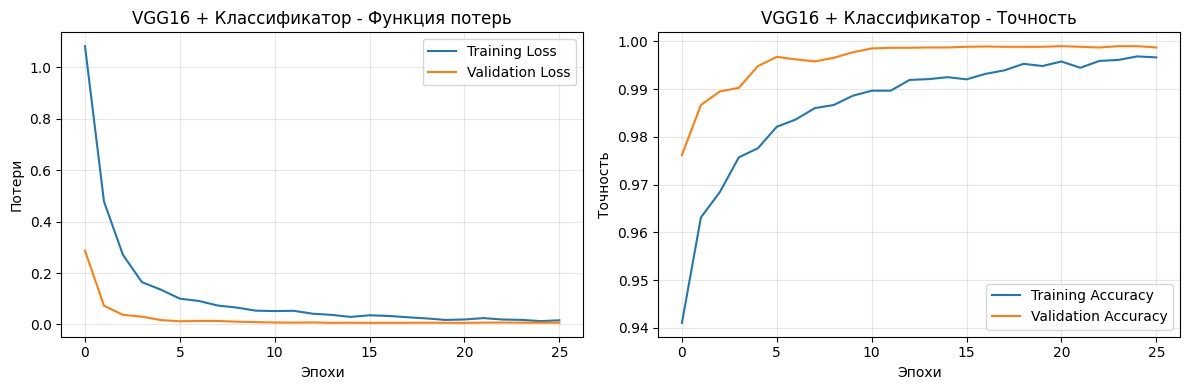

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('VGG16 + Классификатор - Функция потерь')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 + Классификатор - Точность')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
test_loss, test_accuracy = classifier.evaluate(test_features, test_labels, verbose=1)
print(f"Тестовые потери: {test_loss:.4f}")
print(f"Тестовая точность: {test_accuracy:.4f}")

462/462 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9987 - loss: 0.0064
Тестовые потери: 0.0064
Тестовая точность: 0.9987


### Предсказание на тестовых данных

In [10]:
def predict_with_vgg(model, vgg_base, image_path):
    """Предсказание для одного изображения"""
    # Загрузка и подготовка изображения
    img = keras.preprocessing.image.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Извлечение признаков
    features = vgg_base.predict(img_array, verbose=0)

    # Предсказание
    prediction = model.predict(features, verbose=0)[0][0]
    class_name = "кошка" if prediction < 0.5 else "собака"
    confidence = (1 - prediction) if prediction < 0.5 else prediction

    # Визуализация
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f'VGG16 + Классификатор\nПредсказание: {class_name}\nУверенность: {confidence:.2%}')
    plt.axis('off')
    plt.show()

    return class_name, confidence

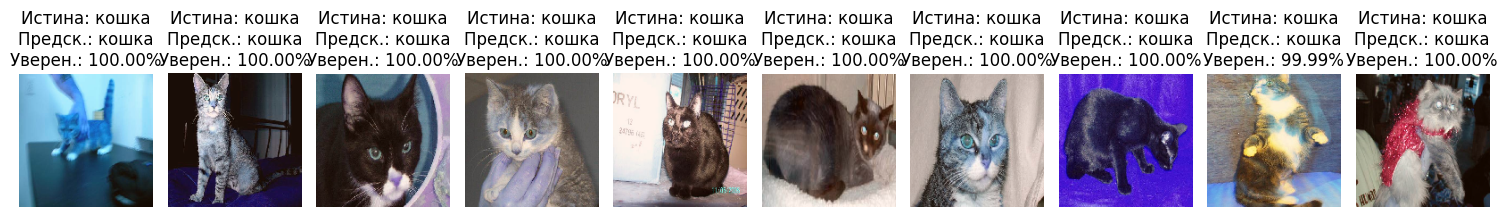

In [11]:
test_images, test_true_labels = next(test_generator)
num_demo = min(10, BATCH_SIZE)

plt.figure(figsize=(15, 3))
for i in range(num_demo):
    img_array = test_images[i]
    img_array = np.expand_dims(img_array, axis=0)

    features = vgg_base.predict(img_array, verbose=0)
    prediction = classifier.predict(features, verbose=0)[0][0]

    true_label = "кошка" if test_true_labels[i] == 0 else "собака"
    predicted_class = "кошка" if prediction < 0.5 else "собака"
    confidence = (1 - prediction) if prediction < 0.5 else prediction

    plt.subplot(1, num_demo, i + 1)
    img_display = test_images[i]
    img_display = img_display - img_display.min()
    img_display = img_display / img_display.max()

    plt.imshow(img_display)
    plt.title(f'Истина: {true_label}\nПредск.: {predicted_class}\nУверен.: {confidence:.2%}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### Создание полной модели

In [13]:
inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = vgg_base(inputs, training=False)  # VGG16 в режиме inference
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(512, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

full_model = keras.Model(inputs, outputs)

full_model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Сохраняем полную модель
full_model.save('models/full_vgg_model.h5')